In [1]:
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2008/VOCtrainval_14-Jul-2008.tar

--2025-04-13 13:55:07--  http://host.robots.ox.ac.uk/pascal/VOC/voc2008/VOCtrainval_14-Jul-2008.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.152
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 577034240 (550M) [application/x-tar]
Saving to: ‘VOCtrainval_14-Jul-2008.tar’

VOCtrainval_14-Jul- 100%[===================>] 550.30M  21.2MB/s    in 28s     

2025-04-13 13:55:35 (19.9 MB/s) - ‘VOCtrainval_14-Jul-2008.tar’ saved [577034240/577034240]



In [2]:
!tar -xvf VOCtrainval_14-Jul-2008.tar

Streaming output truncated to the last 5000 lines.
VOCdevkit/VOC2008/JPEGImages/2008_002811.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002813.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002814.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002817.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002820.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002823.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002826.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002829.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002830.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002831.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002834.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002835.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002838.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002842.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002843.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002845.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002847.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002848.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002850.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002852.jpg
VOCdevkit/VOC2008/JPEGImages/2008_002854.jpg
VOCd

In [3]:
!pip install scikit-learn

In [12]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import xml.etree.ElementTree as ET
from sklearn.metrics import average_precision_score
import glob
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
# Paths to VOC2008 dataset (adjust these to your local paths)
DATA_PATH = '/content/VOCdevkit/VOC2008/'
IMG_PATH = os.path.join(DATA_PATH, 'JPEGImages')
ANN_PATH = os.path.join(DATA_PATH, 'Annotations')
TRAINVAL_LIST = os.path.join(DATA_PATH, 'ImageSets/Main/trainval.txt')

In [6]:
# 20 classes as per VOC2008
CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair',
    'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor'
]
NUM_CLASSES = len(CLASSES)

# Image size for ResNet50
IMG_SIZE = 224

In [7]:
def parse_annotations(ann_file):
    """Parse XML annotation file to get binary labels for each class."""
    tree = ET.parse(ann_file)
    root = tree.getroot()
    labels = np.zeros(NUM_CLASSES, dtype=np.float32)
    for obj in root.findall('object'):
        name = obj.find('name').text
        if name in CLASSES:
            labels[CLASSES.index(name)] = 1.0
    return labels

def load_data():
    """Load image paths and labels from trainval.txt."""
    with open(TRAINVAL_LIST, 'r') as f:
        image_ids = [line.strip() for line in f]

    image_paths = []
    labels = []
    for img_id in image_ids:
        img_path = os.path.join(IMG_PATH, f'{img_id}.jpg')
        ann_path = os.path.join(ANN_PATH, f'{img_id}.xml')
        if os.path.exists(img_path) and os.path.exists(ann_path):
            image_paths.append(img_path)
            labels.append(parse_annotations(ann_path))

    return np.array(image_paths), np.array(labels)

def create_data_generator(image_paths, labels, batch_size=32, augment=False):
    """Create a data generator for loading and preprocessing images."""
    if augment:
        datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )
    else:
        datagen = ImageDataGenerator(rescale=1./255)

    def gen():
        for i in range(len(image_paths)):
            img = tf.keras.preprocessing.image.load_img(
                image_paths[i], target_size=(IMG_SIZE, IMG_SIZE)
            )
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            yield img_array, labels[i]

    dataset = tf.data.Dataset.from_generator(
        gen,
        output_types=(tf.float32, tf.float32),
        output_shapes=([IMG_SIZE, IMG_SIZE, 3], [NUM_CLASSES])
    )
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


In [8]:
def build_model():
    """Build a multi-label classification model using ResNet50."""
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(NUM_CLASSES, activation='sigmoid')(x)  # Sigmoid for multi-label
    model = Model(inputs=base_model.input, outputs=predictions)

    # Freeze base model layers initially
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
def compute_map(y_true, y_pred):
    """Compute Mean Average Precision (mAP) across all classes."""
    ap_scores = []
    for i in range(NUM_CLASSES):
        if np.sum(y_true[:, i]) > 0:  # Only compute AP for classes present in ground truth
            ap = average_precision_score(y_true[:, i], y_pred[:, i])
            ap_scores.append(ap)
    return np.mean(ap_scores) if ap_scores else 0.0

Loaded 4332 images with labels.
Epoch 1/5
    109/Unknown 26s 150ms/step - accuracy: 0.4774 - loss: 0.2271

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


109/109 ━━━━━━━━━━━━━━━━━━━━ 36s 238ms/step - accuracy: 0.4780 - loss: 0.2265 - val_accuracy: 0.5352 - val_loss: 0.1394
Epoch 2/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 167ms/step - accuracy: 0.6648 - loss: 0.0931 - val_accuracy: 0.5386 - val_loss: 0.1398
Epoch 3/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 162ms/step - accuracy: 0.7061 - loss: 0.0721 - val_accuracy: 0.5340 - val_loss: 0.1420
Epoch 4/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - accuracy: 0.7289 - loss: 0.0583 - val_accuracy: 0.5271 - val_loss: 0.1489
Epoch 5/5
109/109 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.7320 - loss: 0.0474 - val_accuracy: 0.5271 - val_loss: 0.1668
Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 84s 433ms/step - accuracy: 0.6897 - loss: 0.0698 - val_accuracy: 0.5952 - val_loss: 0.1323
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 52s 277ms/step - accuracy: 0.7444 - loss: 0.0485 - val_accuracy: 0.5917 - val_loss: 0.1296
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 30s 273ms/step - accuracy: 0.7518 - loss: 0.0406 - val_acc

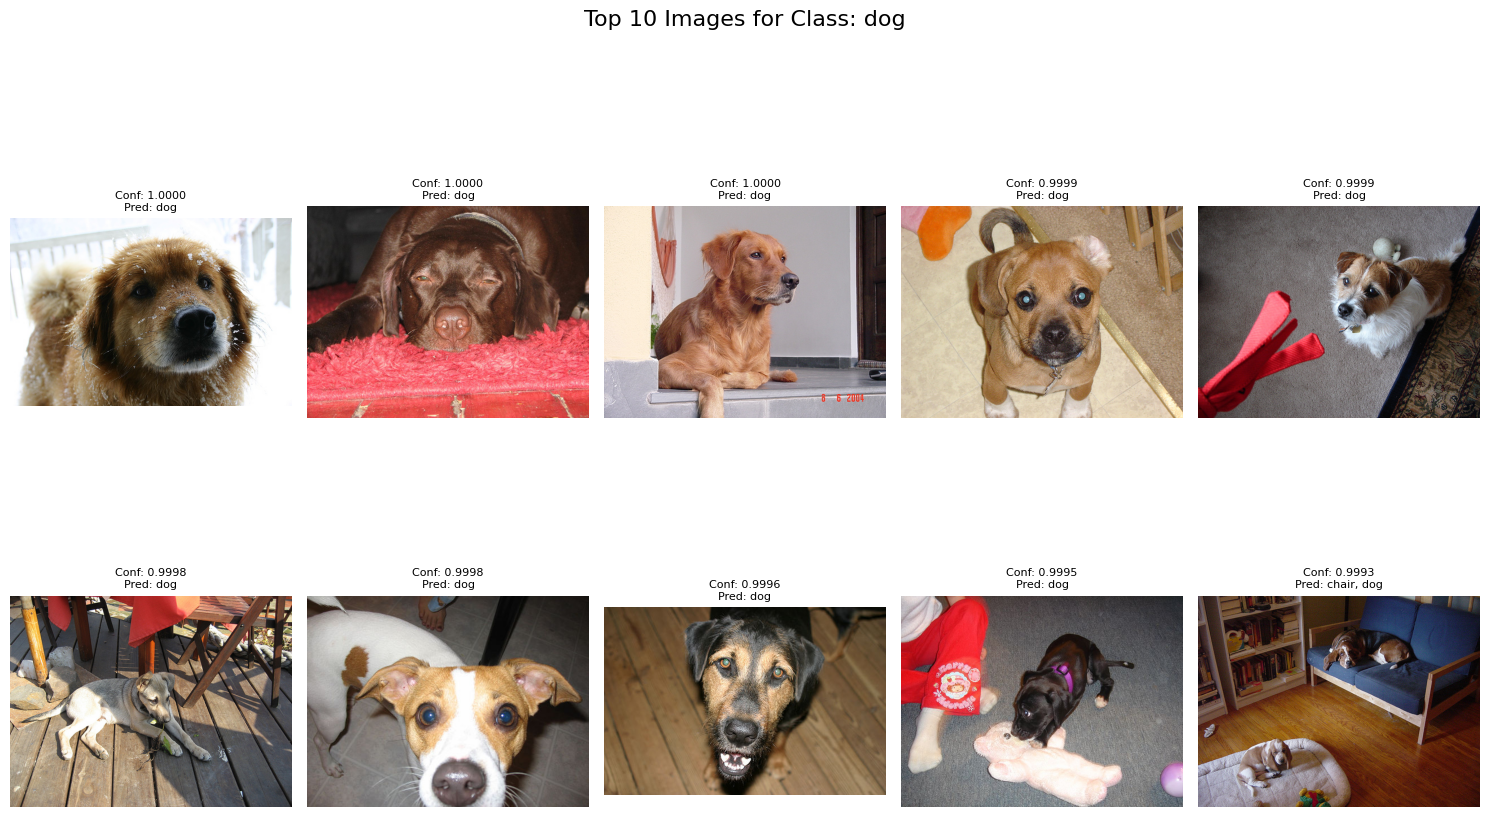

In [13]:
def main():
    # Load data
    image_paths, labels = load_data()
    print(f'Loaded {len(image_paths)} images with labels.')

    # Split into train and validation (80-20 split)
    split_idx = int(0.8 * len(image_paths))
    train_paths, val_paths = image_paths[:split_idx], image_paths[split_idx:]
    train_labels, val_labels = labels[:split_idx], labels[split_idx:]

    # Create data generators
    train_dataset = create_data_generator(train_paths, train_labels, augment=True)
    val_dataset = create_data_generator(val_paths, val_labels, augment=False)

    # Build and train model
    model = build_model()

    # Train with frozen base layers
    model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=5,
        verbose=1
    )

    # Unfreeze some layers and fine-tune
    for layer in model.layers[:100]:  # Unfreeze later layers
        layer.trainable = True
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),  # Lower learning rate for fine-tuning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,
        verbose=1
    )

    # Evaluate on validation set
    val_pred = []
    val_true = []
    for imgs, lbls in val_dataset:
        pred = model.predict(imgs)
        val_pred.append(pred)
        val_true.append(lbls)
    val_pred = np.concatenate(val_pred, axis=0)
    val_true = np.concatenate(val_true, axis=0)

    mAP = compute_map(val_true, val_pred)
    print(f'Validation mAP: {mAP:.4f}')

  # Rank and display top 10 images for a specific class
    target_class = 'dog'  # You can change this to any class in CLASSES (e.g., 'cat', 'car')
    class_idx = CLASSES.index(target_class)
    print(f"\nRanking images by confidence for class: {target_class}")

    # Get confidence scores for the target class
    confidences = val_pred[:, class_idx]
    # Create a list of (image_path, confidence, prediction) tuples
    image_confidence_pairs = list(zip(val_paths, confidences, val_pred))
    # Sort by confidence in descending order
    image_confidence_pairs.sort(key=lambda x: x[1], reverse=True)
    top_10 = image_confidence_pairs[:10]

    # Display the top 10 images
    plt.figure(figsize=(15, 10))
    for i, (img_path, confidence, pred) in enumerate(top_10):
        # Load and display the image
        img = Image.open(img_path)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        # Get predicted labels (classes with confidence > 0.5)
        predicted_labels = [CLASSES[j] for j in range(len(pred)) if pred[j] > 0.5]
        title = f"Conf: {confidence:.4f}\nPred: {', '.join(predicted_labels)}"
        plt.title(title, fontsize=8)
        plt.axis('off')
    plt.suptitle(f"Top 10 Images for Class: {target_class}", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Save model
    model.save('voc2008_classifier.keras')  # Updated to Keras format as recommended

if __name__ == '__main__':
    main()